# Generating Waveforms

ripple provides a set of waveform models as callable Python classes.
Each model takes a frequency (or time) array and a dictionary of
physical parameters, and returns the two gravitational-wave polarizations
$h_+$ and $h_\times$ as JAX arrays.

Because ripple is built on JAX, every waveform is:
- **Differentiable** — gradients via `jax.grad` / `jax.jacobian`
- **JIT-compilable** — fast repeated evaluation via `jax.jit`
- **Vectorisable** — batch evaluation via `jax.vmap`

## Example: IMRPhenomD

`IMRPhenomD` models a non-precessing, aligned-spin BBH merger.
The only constructor argument is `f_ref`, the reference frequency (in Hz)
at which the phase is defined (default: 20 Hz).

The parameter dictionary uses:
- `M_c` — chirp mass $\mathcal{M}$ in solar masses
- `eta` — symmetric mass ratio $\eta = m_1 m_2 / (m_1+m_2)^2 \in (0, 0.25]$
- `s1_z`, `s2_z` — aligned spin components $\chi_{1z}, \chi_{2z} \in [-1, 1]$
- `d_L` — luminosity distance in Mpc
- `phase_c` — coalescence phase in radians
- `iota` — inclination angle in radians

In [1]:
import jax
import jax.numpy as jnp
import ripplegw
jax.config.update("jax_enable_x64", True)  # Use double precision for better accuracy

# Frequency grid: 20 Hz to 512 Hz at 0.25 Hz resolution
f_low = 20.0   # Hz
f_high = 512.0  # Hz
delta_f = 0.25   # Hz
frequency = jnp.arange(f_low, f_high, delta_f)

# BBH parameters
params_bbh = {
    "M_c": 28.3,   # chirp mass [Msun]
    "eta": 0.247,  # symmetric mass ratio
    "s1_z": 0.0,   # primary spin z-component
    "s2_z": 0.0,   # secondary spin z-component
    "d_L": 440.0,  # luminosity distance [Mpc]
    "phase_c": 0.0,
    "iota": 2.0,
}

waveform = ripplegw.IMRPhenomD(f_ref=20.0)
polarizations = waveform(frequency, params_bbh)

hp = polarizations["p"]  # h_+
hc = polarizations["c"]  # h_x

print(f"h+ shape: {hp.shape}, dtype: {hp.dtype}")

h+ shape: (1968,), dtype: complex128


### Visualise the frequency-domain waveform

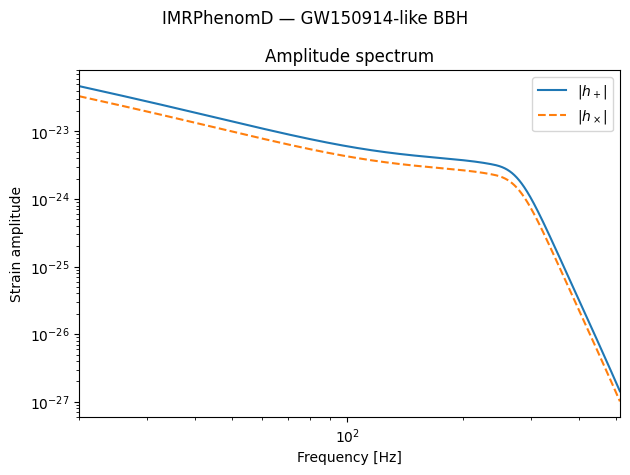

In [2]:
import matplotlib.pyplot as plt

plt.loglog(frequency, jnp.abs(hp), label=r"$|h_+|$")
plt.loglog(frequency, jnp.abs(hc), label=r"$|h_\times|$", ls="--")
plt.xlim(f_low, f_high)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Strain amplitude")
plt.title("Amplitude spectrum")
plt.legend()

plt.suptitle("IMRPhenomD — GW150914-like BBH")
plt.tight_layout()
plt.show()

## Differentiability

Because ripple uses JAX, you can compute gradients of the waveform with
respect to any parameter.  This is key for gradient-based inference.

Here we compute the gradient of the total strain power with respect to
the chirp mass $\mathcal{M}$.

In [3]:
def total_power(M_c):
    p = {**params_bbh, "M_c": M_c}
    h = ripplegw.IMRPhenomD()(frequency, p)
    return jnp.sum(jnp.abs(h["p"]) ** 2)

print(f"power = {total_power(params_bbh['M_c']):.10e}")
grad_Mc = jax.grad(total_power)(params_bbh["M_c"])
print(f"d(power)/d(M_c) = {grad_Mc:.10e}")

power = 1.1431027888e-43
d(power)/d(M_c) = 5.8731355504e-45


## JIT compilation

Wrap the call in `jax.jit` for fast repeated evaluation — e.g., inside a
likelihood or sampler loop.

In [4]:
fast_waveform = jax.jit(waveform)

# First call traces and compiles
_ = fast_waveform(frequency, params_bbh)

# Subsequent calls are fast
import time
t0 = time.perf_counter()
for _ in range(100):
    pol = fast_waveform(frequency, params_bbh)
pol["p"].block_until_ready()
print(f"100 waveform evaluations: {time.perf_counter() - t0:.3f} s")

100 waveform evaluations: 0.025 s


## Switching waveform models

All waveform classes share the same `__call__` interface, so swapping
models only requires changing one line.  `waveform_preset` is a
convenience dictionary mapping name strings to classes.

In [5]:
print("Available waveforms:", list(ripplegw.waveform_preset.keys()))

# Swap IMRPhenomD -> IMRPhenomXAS (same parameter keys)
for name, cls in [("IMRPhenomD", ripplegw.IMRPhenomD),
                  ("IMRPhenomXAS", ripplegw.IMRPhenomXAS)]:
    h = cls()(frequency, params_bbh)
    print(f"{name}: max|h+| = {jnp.max(jnp.abs(h['p'])):.3e}")

Available waveforms: ['IMRPhenomD', 'IMRPhenomPv2', 'TaylorF2', 'IMRPhenomD_NRTidalv2', 'IMRPhenomXAS', 'IMRPhenomXAS_NRTidalv3', 'IMRPhenomXPHM', 'SineGaussian']
IMRPhenomD: max|h+| = 4.678e-23
IMRPhenomXAS: max|h+| = 4.667e-23


## Summary

The ripple interface is:

```python
waveform = ripplegw.IMRPhenomD(f_ref=20.0)
polarizations = waveform(frequency, params)
hp, hc = polarizations["p"], polarizations["c"]
```

The same pattern applies to every model.  Because all waveforms are pure
JAX functions, they compose naturally with `jax.grad`, `jax.jit`, and
`jax.vmap` for gradient-based inference and GPU-accelerated batch
evaluation.